## Latest scVelo using the un/splice count matrices from kb rather than parse

- reason for this: Parse's split-pipe would not accept my geneext gtf file!
- i did use parse to make the BAM file that was used as input for geneext tho
- will be taking a lot of code from old scvelo notebook ofc
- but will also be following pachter lab snRNASeq for scvelo tutorial
    - https://www.kallistobus.tools/tutorials/kb_velocity/python/kb_velocity/

### Importing modules

In [13]:
import gc
import os
import sys
import glob
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse
import scvelo as scv
import anndata as ad
import scipy.io as sio
from scipy.sparse import csr_matrix
import dask.dataframe as dd
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar
import decoupler as dc
import doubletdetection as dd
import cellsweep
from cellsweep import denoise_count_matrix
import cellsweep.utils.visualization_utils as cs_utils
ProgressBar().register()

## Import kb adata and (un)splice matrices

In [ ]:
kb_dir= "/home/FCAM/jbriseno/JB_Nyholm_Lab/Sept2026_Ch2_BulkDataV3_ReAnalyses/kb_dir/MWB_kb/counts_unfiltered/"

In [ ]:
#spliced

#loading info
output_file = 'spliced_adata.h5ad'
adata=sc.read_mtx(os.path.join(kb_dir, 'spliced.mtx'))
adata_bc=pd.read_csv(os.path.join(kb_dir, 'spliced.barcodes.txt'), header=None)
adata_features=pd.read_csv(os.path.join(kb_dir, 'spliced.genes.txt'), header=None, sep='\t')
adata #do NOT transpose - 53617 is genes and 53860 is bc

#barcode info
adata.obs_names = adata_bc[0].values

#genes info
adata.var_names = adata_features[0].values  # Use gene IDs
adata.var['gene_id'] = adata_features[0].values  # Save gene IDs as metadata
#adata.var = adata.var.set_index('gene_id')

adata.write_h5ad(os.path.join(kb_dir, output_file))

In [ ]:
#unspliced

#loading info
output_file = 'unspliced_adata.h5ad'
adata=sc.read_mtx(os.path.join(kb_dir, 'unspliced.mtx'))
adata_bc=pd.read_csv(os.path.join(kb_dir, 'unspliced.barcodes.txt'), header=None)
adata_features=pd.read_csv(os.path.join(kb_dir, 'unspliced.genes.txt'), header=None, sep='\t')
adata #do NOT transpose - 53617 is genes and 53860 is bc

#barcode info
adata.obs_names = adata_bc[0].values

#genes info
adata.var_names = adata_features[0].values  # Use gene IDs
adata.var['gene_id'] = adata_features[0].values  # Save gene IDs as metadata
#adata.var = adata.var.set_index('gene_id')

adata.write_h5ad(os.path.join(kb_dir, output_file))

In [ ]:
#loading in both splice/unsplice adatas

splice_mat = sc.read_h5ad(os.path.join(kb_dir, 'spliced_adata.h5ad'))
unsplice_mat = sc.read_h5ad(os.path.join(kb_dir, 'unspliced_adata.h5ad'))

In [ ]:
#load combined object
adata = ad.read_h5ad("/home/FCAM/jbriseno/JB_Nyholm_Lab/Sept2026_Ch2_BulkDataV3_ReAnalyses/kb_dir/MWB_kb/counts_unfiltered/adata.h5ad")

In [ ]:
!jupyter --version

In [ ]:
# First find the intersecting barcodes and genes across both matrices
shared_barcodes = splice_mat.obs_names.intersection(unsplice_mat.obs_names)
shared_genes = splice_mat.var_names.intersection(unsplice_mat.var_names)

print(f"\nSpliced cells: {splice_mat.n_obs} | Unspliced cells: {unsplice_mat.n_obs}")
print(f"Matching shared cells found: {len(shared_barcodes)}")

In [ ]:
#then subset both objects to only include the shared cells and genes
splice_mat = splice_mat[shared_barcodes, shared_genes].copy()
unsplice_mat = unsplice_mat[shared_barcodes, shared_genes].copy()

In [ ]:
# Inject the explicit layers that scVelo requires
adata.layers['spliced'] = splice_mat.X
adata.layers['unspliced'] = unsplice_mat.X

In [ ]:
# Standard clean up
adata.var_names_make_unique()
adata.obs_names_make_unique()

In [ ]:
print("\nSuccessfully aligned! Final AnnData object shape:")
print(adata)

## Add NCBI gene annots

In [ ]:
#loading in ncbi feature tables 
ncbi_res = pd.read_csv('/labs/Nyholm/Es_V3_Genome/GCF_053919585.1/GCF_053919585.1_ASM5391958v1_feature_table.txt', sep='\t')
df = ncbi_res
df

In [ ]:
#dropping all columns besides geneID and description
df1 = df[['symbol', 'name']]
df1

In [ ]:
#first replace spaces and commas in description with underscores
df1['name'] = df1['name'].str.replace(' ', '_')
df1['name'] = df1['name'].str.replace(',', '_')
df1

In [ ]:
#remove duplicates
df1.drop_duplicates(subset='symbol',
                    keep='first',
                    inplace=True)
df1

In [ ]:
#join geneID and description into new column by an underscore but keep geneID column still to join geneIDs
df1['gene_id_description'] = (df1['name'].astype(str) + "_" + df1['symbol'].astype(str))
df1
#uncharacterized genes/proteins already have this so just want to add where this isn't apparent - did this with regrex in next cell

In [ ]:
# RegEx Breakdown:
# (_[a-zA-Z0-9]+) -> Capture group 1: matches an underscore followed by alphanumeric characters
# \1$             -> Backreference: matches the exact same group copy right at the end ($) of the string
# r'\1'           -> Replaces the double match with just one single copy of the group

df1['gene_id_description'] = df1['gene_id_description'].str.replace(r'(_[a-zA-Z0-9]+)\1$', r'\1', regex=True)
df1

In [ ]:
#adding new column for gene symbols in adata
adata.var['symbol'] = adata.var.index
adata.var

In [ ]:
#make temp adata to test
tmp = adata

In [ ]:
#merge updated ncbi annots on gene symbols
tmp.var = pd.merge(tmp.var, df1, on='symbol', how='left')

In [ ]:
#fifth - sanity check if genes are unique
tmp.var_names.is_unique

In [ ]:
#sixth - resetting var names index 
tmp.var.set_index("gene_id_description", inplace=True)
tmp.var

In [ ]:
#seems i have NA values...
tmp.var.isna().any()

In [ ]:
#final - tunring back into adata
adata.var = tmp.var
adata.var

## Save adata

In [ ]:
#Force AnnData to allow writing modern nullable string formats
#ad.settings.allow_write_nullable_strings = True
#pd.options.future.infer_string = True

adata.write_h5ad(filename="kb_scvelo_adata.h5ad")
#pandas version error thrown here so run the top commands prior to saving h5ads

## Read object in

In [ ]:
adata = ad.read_h5ad(filename="kb_adata.h5ad")

In [ ]:
adata

## Test for library saturation¶


In [ ]:
fig, ax = plt.subplots(figsize=(7,7))

#histogram definition
bins = [1500, 1500] # number of bins


x = np.asarray(adata.X.sum(axis=1))[:,0]
y = np.asarray(np.sum(adata.X>0, axis=1))[:,0]

# histogram the data
hh, locx, locy = np.histogram2d(x, y, bins=bins)

# Sort the points by density, so that the densest points are plotted last
z = np.array([hh[np.argmax(a<=locx[1:]),np.argmax(b<=locy[1:])] for a,b in zip(x,y)])
idx = z.argsort()
x2, y2, z2 = x[idx], y[idx], z[idx]


s = ax.scatter(x2, y2, c=z2, cmap='Greens')  
fig.colorbar(s, ax=ax)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("UMI Counts")
ax.set_ylabel("Genes Detected")

ax.set_xlim((0.5, 45000))
ax.set_ylim((0.5,2000))

plt.show()
fig.savefig('seq_sat_density_plot.png', dpi=200)

## CellSweep to clean of noisy cells
- keep getting errors on scvelo below
- likely need to clean the data first
- will use cellsweep for this

In [ ]:
import cellsweep.utils.visualization_utils as cs_utils_vis
import cellsweep.utils as cs_utils

In [ ]:
adata_raw=adata

In [ ]:
expected_cells = 5000

umi_cutoff = cs_utils_vis.knee_plot(adata_raw, expected_cells=expected_cells, out_path=("figures/cellsweep_knee_plot.png"))
adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff)

### Perform QC and assign cell types


In [ ]:
min_genes = 10
max_mt_percent = None #25, how to get MT genes? find all gene IDs from mt genome and label in data
remove_doublets = True

In [ ]:
adata_celltype = adata_raw[~adata_raw.obs["is_empty"]].copy()
adata_celltype

In [ ]:
if min_genes is not None:
    sc.pp.filter_cells(adata_celltype, min_genes=min_genes)

sc.pp.filter_genes(adata_celltype, min_cells=1)
adata_celltype

In [ ]:
adata_celltype

In [ ]:
if remove_doublets:
    sc.pp.scrublet(adata_celltype)
    adata_celltype = adata_celltype[~adata_celltype.obs["predicted_doublet"]]

In [ ]:
adata

In [ ]:
adata.obs

In [ ]:
# Set figure parameters
scv.settings.presenter_view = True # set max width size for presenter view
scv.set_figure_params("scvelo") # for beautified visualization
scv.set_figure_params(figsize=(5.5,4), dpi=300, format="png", dpi_save=300, transparent=False, facecolor="white", fontsize=8)
cluster_colors=sns.color_palette("pastel", 28)

In [ ]:
sc.pl.umap(adata, color=['n_counts','alpha_hat'])

In [ ]:
adata_celltype.layers["counts"] = adata_celltype.X.copy()
sc.pp.normalize_total(adata_celltype, target_sum=1e4)
sc.pp.log1p(adata_celltype)
sc.pp.highly_variable_genes(adata_celltype, n_top_genes=2000)
sc.tl.pca(adata_celltype, svd_solver="arpack", random_state=42)
sc.pp.neighbors(adata_celltype, n_neighbors=15, n_pcs=50)
sc.tl.leiden(adata_celltype, flavor="igraph", n_iterations=2, resolution=0.8, random_state=42, key_added='cellsweep_leiden')
sc.tl.umap(adata_celltype)

In [ ]:
adata_raw.obs["celltype"] = adata_celltype.obs["cellsweep_leiden"].cat.add_categories(["empty"]).reindex(adata_raw.obs.index).fillna("empty")

adata_raw_cells_filtered = adata_raw[(adata_raw.obs["is_empty"] | adata_raw.obs_names.isin(adata_celltype.obs_names))].copy()  # keep empty droplets and cells that passed QC (min_genes, MT%, not doublets)
adata_raw_cells_filtered

In [ ]:
adata_raw_cells_filtered.X

### Run CellSweep

Requires columns adata.obs["is_empty"] and adata.obs["celltype"] to be present

In [ ]:
data_dir='/home/FCAM/jbriseno/JB_Nyholm_Lab/Sept2026_Ch2_BulkDataV3_ReAnalyses/ParseV2_GenomeV3/analysis/scvelo/cellsweep'

adata_cellsweep_path = os.path.join(data_dir, "adata_cellsweep.h5ad")
log_file = os.path.join(data_dir, "cellsweep.log")

In [ ]:
#drop NAs from adata.var here
# Replace 'your_column_name' with the actual column you are checking
valid_features = adata_raw_cells_filtered.var["symbol"].notna()

# Slice the entire AnnData object (this automatically updates adata.X and adata.var)
adata_raw_cells_filtered = adata_raw_cells_filtered[:, valid_features].copy()

#and have to do the same for name too?
valid_features = adata_raw_cells_filtered.var["name"].notna()
adata_raw_cells_filtered = adata_raw_cells_filtered[:, valid_features].copy()

In [ ]:
adata_cellsweep = denoise_count_matrix(adata_raw_cells_filtered, adata_out=adata_cellsweep_path, log_file=log_file, threads=2)

### Filter empty droplets

In [ ]:
adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
adata_cellsweep

### Plot a histogram of alpha_hat (predicted ambient fraction for each cell)

In [ ]:
import cellsweep
from cellsweep import denoise_count_matrix
import cellsweep.utils.visualization_utils as cs_utils

In [ ]:
cs_utils.plot_histogram(adata_cellsweep, col="alpha_hat", out_path=os.path.join(data_dir, "alpha_hat_histogram.png"), kind="cdf")

### Let's use a threshold to remove noisy cells from our Anndata object

In [ ]:
alpha_hat_threshold = 0.3
adata_cellsweep = adata_cellsweep[adata_cellsweep.obs["alpha_hat"] <= alpha_hat_threshold].copy()
adata_cellsweep

### Let's make some scatterplots to visualize how much CellSweep modified our counts
be sure to read in raw data too!

In [ ]:
# Standard clean up
adata_raw.var_names_make_unique()
adata_raw.obs_names_make_unique()

adata_cellsweep.var_names_make_unique()
adata_cellsweep.obs_names_make_unique()

In [ ]:
adata_raw.var_names_make_unique()

In [ ]:
adata_cellsweep.var[adata_cellsweep.var.index.duplicated(keep=False)]

In [ ]:
#have to drop NAs from raw too 
#drop NAs from adata.var here
# Replace 'your_column_name' with the actual column you are checking
valid_features = adata_raw.var["symbol"].notna()

# Slice the entire AnnData object (this automatically updates adata.X and adata.var)
adata_raw = adata_raw[:, valid_features].copy()

#and have to do the same for name too?
valid_features = adata_raw.var["name"].notna()
adata_raw = adata_raw[:, valid_features].copy()

In [ ]:
cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="raw", y_axis="cellsweep", out_path=os.path.join(f"cellsweep_vs_raw_matrix_expression_scatterplot.png"), show=True)
cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", out_path=os.path.join(f"cellsweep_vs_raw_cell_expression_scatterplot.png"), show=True)
cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", out_path=os.path.join(f"cellsweep_vs_raw_gene_expression_scatterplot.png"), show=True)

### Let's see which genes contributed most to the ambient signal

In [ ]:
cs_utils.plot_histogram(adata_cellsweep, adata_df="var", col="ambient_hat", out_path=os.path.join("ambient_hat_histogram.png"), kind="pdf", ylog=True)
cs_utils.print_top_ambient_genes(adata_cellsweep, top_n=20)

### If you want to work with the noise matrix, simply subtract cellsweep from raw

In [ ]:
adata_cellsweep.layers["noise"] = adata_cellsweep.layers["raw"] - adata_cellsweep.X

### If you prefer the raw matrix over the CellSweep-corrected matrix, you can access the raw matrix in adata.layers["raw"]

In [ ]:
adata_cellsweep.X = adata_cellsweep.layers["raw"]

In [ ]:
adata_cellsweep

### Final save

In [ ]:
adata_cellsweep.write_h5ad(filename='kb_cellsweep_adata.h5ad')

## Run through cell preprocessing and clustering.


In [ ]:
adata = sc.read_h5ad(filename='kb_cellsweep_adata.h5ad')

In [ ]:
adata

In [ ]:
#sc.pp.filter_cells(adata, min_genes=10)
#sc.pp.filter_genes(adata, min_cells=1)
#sc.pp.normalize_total(adata, target_sum=1e4)
#sc.pp.log1p(adata)
#sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata

In [ ]:
scv.pp.filter_genes(adata, min_shared_counts=10)
scv.pp.normalize_per_cell(adata)
sc.pp.log1p(adata)
adata

In [ ]:
sc.tl.pca(adata, svd_solver="arpack")
#sc.pp.pca(adata, n_comps=30)
scv.pp.neighbors(adata, n_neighbors=30, n_pcs=30)
sc.tl.umap(adata)

In [ ]:
sc.tl.leiden(adata, flavor="igraph", n_iterations=2, resolution=0.5, random_state=42, key_added='leiden0.5')
sc.tl.leiden(adata, flavor="igraph", n_iterations=2, resolution=0.8, random_state=42, key_added='leiden0.8')
sc.tl.leiden(adata, flavor="igraph", n_iterations=2, resolution=1.0, random_state=42, key_added='leiden1.0')

In [ ]:
#running the scvelo velocity estimations and calculations
scv.pp.moments(adata, n_neighbors=30, n_pcs=30, use_highly_variable=False)
scv.tl.velocity(adata, mode="deterministic", vkey="velocity", use_highly_variable=False)
scv.tl.velocity_graph(adata, vkey="velocity", mode_neighbors='connectivities', n_jobs=1)

In [ ]:
#velocity pseudotime
scv.tl.velocity_pseudotime(adata, vkey="velocity")
scv.tl.velocity_confidence(adata, vkey="velocity")

In [ ]:
pip show paga

## Save preproecessed adata
- completed 9.23!

In [ ]:
adata.write_h5ad(filename="kb_cellsweep_scvelo_adata.h5ad")

## Read in preprocessed adata

In [41]:
adata = sc.read_h5ad(filename='kb_cellsweep_scvelo_adata.h5ad')
adata

AnnData object with n_obs × n_vars = 3927 × 824
    obs: 'is_empty', 'celltype', 'init_alpha', 'alpha_hat', 'z_hat', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'leiden0.5', 'leiden0.8', 'leiden1.0', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition'
    var: 'symbol', 'name', 'ambient_profile', 'ambient_hat', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'beta_hat', 'celltype_names', 'celltype_profile', 'celltype_profile_genes', 'leiden0.5', 'leiden0.8', 'leiden1.0', 'log1p', 'loglike', 'neighbors', 'p_hat', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: 'Ms', 'Mu', 'noise', 'raw', 'spliced', 'unspliced', 'velocity', None (.X)

## Visualizing results

In [ ]:

scv.settings.verbosity = 3  # show errors(0), warnings(1), info(2), hints(3)
scv.settings.presenter_view = True  # set max width size for presenter view
scv.set_figure_params('scvelo')  # for beautified visualization

In [ ]:
# Set figure parameters
scv.settings.presenter_view = True # set max width size for presenter view
scv.set_figure_params("scvelo") # for beautified visualization
scv.set_figure_params(figsize=(6,5), dpi=300, format="png", dpi_save=300, transparent=False, facecolor="white", fontsize=8)
cluster_colors=sns.color_palette("pastel", 28)

### (Un)splicing proportions

In [ ]:
adata.var

In [ ]:
scv.pl.proportions(adata, groupby='celltype', save='splice_unsplice_fractions_by_celltype')
scv.pl.proportions(adata, groupby='leiden0.5', save='splice_unsplice_fractions_by_leiden0.5')
scv.pl.proportions(adata, groupby='leiden0.8', save='splice_unsplice_fractions_by_leiden0.8')
scv.pl.proportions(adata, groupby='leiden1.0', save='splice_unsplice_fractions_by_leiden1.0')

### Embeddings

In [ ]:
scv.pl.velocity_embedding_grid(adata, basis="umap", color="celltype",
                               palette=cluster_colors, size=30 ,alpha=0.8 ,fontsize=10, 
                               save="grid_embedding_cellsweep_celltype_sharedgenes10")
scv.pl.velocity_embedding_grid(adata, basis="umap", color="leiden0.5",
                               palette=cluster_colors, size=30 ,alpha=0.8 ,fontsize=10, 
                               save="grid_embedding_leiden0.5_sharedgenes10")
scv.pl.velocity_embedding_grid(adata, basis="umap", color="leiden0.8",
                               palette=cluster_colors, size=30 ,alpha=0.8 ,fontsize=10, 
                               save="grid_embedding_leiden0.8_sharedgenes10")
scv.pl.velocity_embedding_grid(adata, basis="umap", color="leiden1.0",
                               palette=cluster_colors, size=30 ,alpha=0.8 ,fontsize=10, 
                               save="grid_embedding_leiden1_sharedgenes10")

In [ ]:
scv.pl.velocity_embedding_stream(adata, basis="umap", color="celltype",
                               palette=cluster_colors, size=30 ,alpha=0.8 ,fontsize=10, 
                               save="stream_embedding_cellsweep_celltype_sharedgenes10")
scv.pl.velocity_embedding_stream(adata, basis="umap", color="leiden0.5",
                               palette=cluster_colors, size=30 ,alpha=0.8 ,fontsize=10, 
                               save="stream_embedding_leiden0.5_sharedgenes10")
scv.pl.velocity_embedding_stream(adata, basis="umap", color="leiden0.8",
                               palette=cluster_colors, size=30 ,alpha=0.8 ,fontsize=10, 
                               save="stream_embedding_leiden0.8_sharedgenes10")
scv.pl.velocity_embedding_stream(adata, basis="umap", color="leiden1.0",
                               palette=cluster_colors, size=30 ,alpha=0.8 ,fontsize=10, 
                               save="stream_embedding_leiden1_sharedgenes10")

In [ ]:
scv.pl.velocity_embedding(adata, basis="umap", color="celltype",
                               palette=cluster_colors, size=30 ,alpha=0.8 ,fontsize=10, 
                               )
scv.pl.velocity_embedding(adata, basis="umap", color="leiden0.5",
                               palette=cluster_colors, size=30 ,alpha=0.8 ,fontsize=10, 
                               )
scv.pl.velocity_embedding(adata, basis="umap", color="leiden0.8",
                               palette=cluster_colors, size=30 ,alpha=0.8 ,fontsize=10, 
                               )
scv.pl.velocity_embedding(adata, basis="umap", color="leiden1.0",
                               palette=cluster_colors, size=30 ,alpha=0.8 ,fontsize=10, 
                               )

### Interpret the velocities


In [ ]:
#check gene names with this
adata.var[adata.var["name"].str.contains("ela", na=False)]

In [ ]:
#for getting long gene lists printed nicely
gene_list = adata.var[adata.var["symbol"].str.contains("LOC145288272", na=False)].index.tolist()
gene_list

In [ ]:
TF_genes = [
    #TFs
    'uncharacterized_LOC145267028', #HHEX
    'homeobox_protein_cut-like_1_LOC145280019',
    #'homeodomain-interacting_protein_kinase_2-like_LOC145293296',
    'transcription_factor_GATA-3-like_LOC145296204',
    #'microphthalmia-associated_transcription_factor-like_LOC145293784',
    #'transcription_factor_12-like_LOC145245847',
    #'transcription_factor_Dp-1-like_LOC145246751',
    #'transcription_factor_7-like_2_LOC145258331',
    'ETS-related_transcription_factor_Elf-2-like_LOC145259310'
]

ZF_genes=[
    #ZFs
    #there's a lot of these, choosing 3
    'zinc_finger_RNA-binding_protein-like_LOC145270147',
    'MYND-type_zinc_finger-containing_chromatin_reader_ZMYND8-like_LOC145280074',
    'zinc_finger_homeobox_protein_4-like_LOC145284709',
    'zinc_finger_MYM-type_protein_4-like_LOC145291282',
    #'zinc_finger_C3H1_domain-containing_protein-like_LOC145249581',
    #'zinc_finger_MIZ_domain-containing_protein_1-like_LOC145254896',
    #'bromodomain_adjacent_to_zinc_finger_domain_protein_2B-like_LOC145259755',
    #'zinc_finger_protein_1-like_LOC145259962',
    #'bromodomain_adjacent_to_zinc_finger_domain_protein_1A-like_LOC145266380'
]

HNRNP_genes = [
    'heterogeneous_nuclear_ribonucleoprotein_A/B-like_LOC145292954',
    'heterogeneous_nuclear_ribonucleoprotein_A1-like_3_LOC145258173',
    'heterogeneous_nuclear_ribonucleoprotein_A1-like_3_LOC145258177',
    'heterogeneous_nuclear_ribonucleoprotein_U-like_protein_1_LOC145260563'
]

Fe_genes = [
    #Iron regulators
    'hephaestin-like_protein_LOC145283795', #HEPHL1
    'ferritin-1_heavy_chain-like_LOC145246871', #FTH1
    'serotransferrin-1-like_LOC145245829'
]

PRR_genes = [
    #Host-microbe modulators
    'peptidoglycan-recognition_protein_SC2-like_LOC145291335', #PGRP5
    #'uncharacterized_LOC145291120', #TLR homolog
    'toll-like_receptor_2_type-2_LOC145291538', #tlr2
    'scavenger_receptor_cysteine-rich_domain_superfamily_protein-like_LOC145266610'
    ]

GOIs = {"TFs":TF_genes,
        "ZFs":ZF_genes,
        "PRRs":PRR_genes,
        'HNRNPs':HNRNP_genes,
        "Fe Regulators":Fe_genes
}

In [ ]:
scv.pl.velocity(adata, color='leiden0.8',
                var_names=[
                    'uncharacterized_LOC145267028', #HHEX
                    'transcription_factor_GATA-3-like_LOC145296204',
                    'hephaestin-like_protein_LOC145283795', #HEPHL1
                    'peptidoglycan-recognition_protein_SC2-like_LOC145291335', #PGRP5
                    'zinc_finger_MYM-type_protein_4-like_LOC145291282', #ZF
                    'CUGBP_Elav-like_family_member_1_LOC145286304' #ELAV
                           ], 
                ncols=2,
                save='phase_portraits.svg')

In [ ]:
scv.pl.scatter(adata, 'peptidoglycan-recognition_protein_SC2-like_LOC145291335', 
               color=['leiden0.8', 'velocity'],
               vkey="velocity"
               #add_outline='0,1,2'
               )

### Identify important genes


In [ ]:
#first need to swap updated gene names wth gen symbols cause the long names cause errors

# 1. Back up your original long names to a new column so they aren't lost
adata.var["gene_id_description"] = adata.var_names

# 2. Swap the main index (var_names) to use your short gene name column
adata.var_names = adata.var["symbol"].astype(str)

In [ ]:
kwargs = dict(frameon=False, size=10, linewidth=1.5)

scv.tl.rank_velocity_genes(adata, groupby='leiden0.8', min_corr=.3, )

df = pd.DataFrame(adata.uns['rank_velocity_genes']['names'])
df.head()

In [ ]:
#saving these with funct. gene names too
df.to_csv('velocity_genes_df_leiden0.8.csv', index=False)

In [ ]:
scv.pl.scatter(adata, df['0'][:5], ylabel='Cluster 0', color='leiden0.8', add_outline='0', dpi=500, **kwargs)
scv.pl.scatter(adata, df['1'][:5], ylabel='Cluster 1', color='leiden0.8', add_outline='1', dpi=500,**kwargs)
scv.pl.scatter(adata, df['2'][:5], ylabel='Cluster 2', color='leiden0.8', add_outline='2', dpi=500,**kwargs)
scv.pl.scatter(adata, df['3'][:5], ylabel='Cluster 3', color='leiden0.8', add_outline='3', dpi=500,**kwargs)
scv.pl.scatter(adata, df['4'][:5], ylabel='Cluster 4', color='leiden0.8', add_outline='4', dpi=500,**kwargs)
scv.pl.scatter(adata, df['5'][:5], ylabel='Cluster 5', color='leiden0.8', add_outline='5', dpi=500,**kwargs)

In [ ]:
#reswap the temp symbols index with full names again and drop column (this will give erros when trying to save since index cant be same name solumn in adata.var apparently)
adata.var_names = adata.var["gene_id_description"].astype(str)
adata.var.drop("gene_id_description", axis=1, inplace=True)

## Cell cycle velocities 
- doesn't work since I don't have legit IDs for cell cycle genes
- but will try searching for some anyways

In [ ]:
#search for them tho
#check gene names with this
adata.var[adata.var["name"].str.contains("", na=False)]

looks like we have some! label them as such then

In [ ]:
s_genes = ['S_phase_cyclin_A-associated_protein_in_the_endoplasmic_reticulum-like_LOC145276941'
           ]
g2m_genes = ['cyclin-G-associated_kinase-like_LOC145288846',
           'cyclin-dependent_kinase_14-like_LOC145254643'
           ]

In [ ]:
scv.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)

In [ ]:
scv.pl.scatter(adata, color_gradients=['S_score', 'G2M_score'], smooth=True, perc=[5, 95])

what other invert cell cycle genes exist out there?
- looks like E2f1 and Rbf TFs
- Mini c'some modulators Mcm2 – Mcm7
- And Bub1/R1 genes

## Speed and coherence

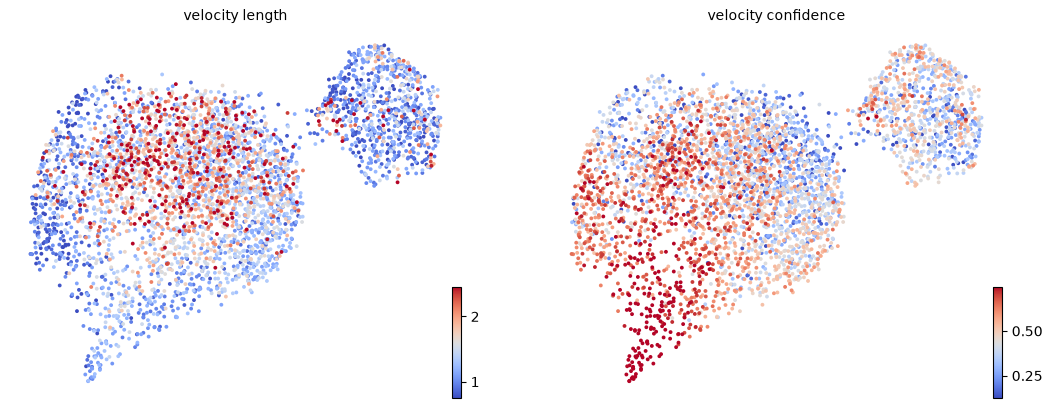

In [24]:
keys = ['velocity_length', 'velocity_confidence']
scv.pl.scatter(adata, color=keys, cmap='coolwarm', perc=[5, 95])

In [25]:
df = adata.obs.groupby('leiden0.8')[keys].mean().T
df.style.background_gradient(cmap='coolwarm', axis=1)

leiden0.8,0,1,2,3,4,5
velocity_length,1.388390,1.368055,1.749630,1.656059,1.154623,1.167063
velocity_confidence,0.382142,0.637471,0.472834,0.398152,0.508033,0.390892


## Velocity graph and pseudotime

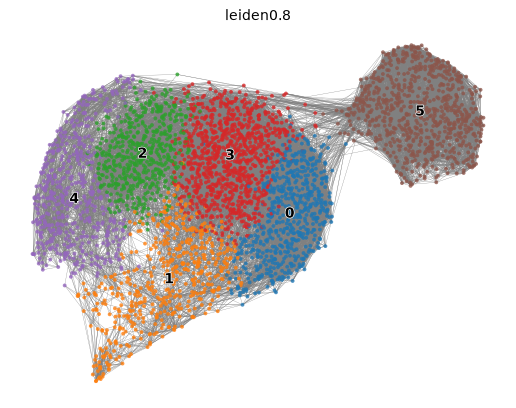

In [21]:
scv.pl.velocity_graph(adata, threshold=.1, color='leiden0.8')

In [36]:
#choosing root cell implcitly
scv.tl.transition_matrix(adata)
scv.tl.terminal_states(adata)

computing terminal states
    identified 0 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


In [ ]:
adata

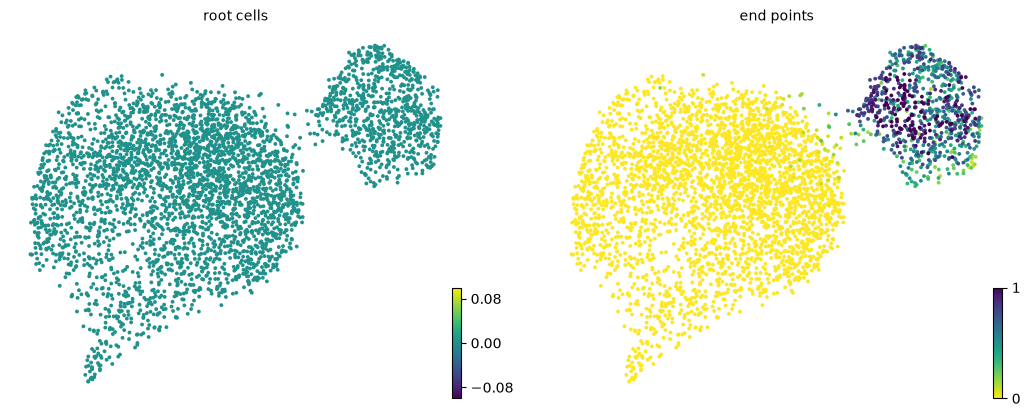

In [42]:
#Visualize the automatically detected root cell and endpoint regions
scv.pl.scatter(adata, color=['root_cells', 'end_points'])

In [43]:
# 2. Extract the cell index with the maximum probability of being a root cell
# argmax handles finding the position implicitly without manual intervention
inferred_root_idx = np.argmax(adata.obs["root_cells"])
inferred_root_idx

np.int64(0)

In [44]:
np.argmax(adata.obs["root_cells"])

np.int64(0)

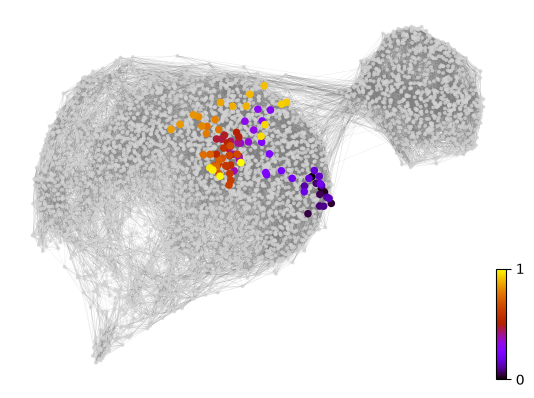

In [45]:
x, y = scv.utils.get_cell_transitions(adata, basis='umap', starting_cell=inferred_root_idx)
ax = scv.pl.velocity_graph(adata, c='lightgrey', edge_width=.05, show=False)
ax = scv.pl.scatter(adata, x=x, y=y, s=120, c='ascending', cmap='gnuplot', ax=ax)

computing terminal states
    identified 0 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


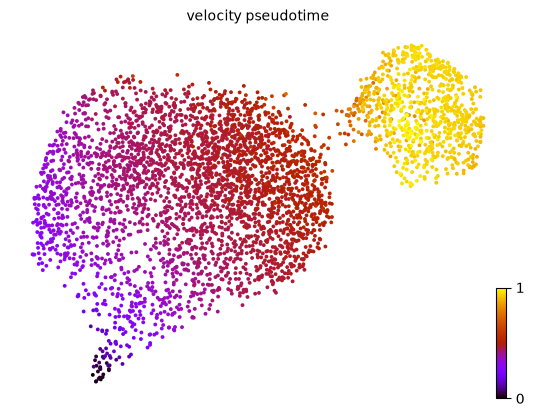

In [46]:
scv.tl.velocity_pseudotime(adata)
scv.pl.scatter(adata, color='velocity_pseudotime', cmap='gnuplot')

## PAGA velocity graph

In [49]:
adata.uns['neighbors']['distances'] = adata.obsp['distances']
adata.uns['neighbors']['connectivities'] = adata.obsp['connectivities']

scv.tl.paga(adata, groups='leiden0.8')
df = scv.get_df(adata, 'paga/transitions_confidence', precision=2).T
df.style.background_gradient(cmap='Blues').format('{:.2g}')

running PAGA using priors: ['velocity_pseudotime']
    finished (0:00:02) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


/tmp/ipykernel_2096562/3123554294.py:5: DeprecationWarning: `get_df` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please `AnnData::get_df` or Scanpy's `scanpy.get.obs_df` or `scanpy.get.var_df`.
  df = scv.get_df(adata, 'paga/transitions_confidence', precision=2).T


,0,1,2,3,4,5
0,0,0,0,0,0,0.39
1,0.64,0,0,1.2,0.15,0
2,0,0,0,1.3,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
5,0,0,0,0,0,0


In [51]:
adata

AnnData object with n_obs × n_vars = 3927 × 824
    obs: 'is_empty', 'celltype', 'init_alpha', 'alpha_hat', 'z_hat', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'leiden0.5', 'leiden0.8', 'leiden1.0', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition'
    var: 'symbol', 'name', 'ambient_profile', 'ambient_hat', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'beta_hat', 'celltype_names', 'celltype_profile', 'celltype_profile_genes', 'leiden0.5', 'leiden0.8', 'leiden1.0', 'log1p', 'loglike', 'neighbors', 'p_hat', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'paga', 'leiden0.8_sizes', 'leiden0.8_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: 'Ms', 'Mu', 'noise', 'raw', 'spliced', 'unspliced', 'velocity', None (.X)

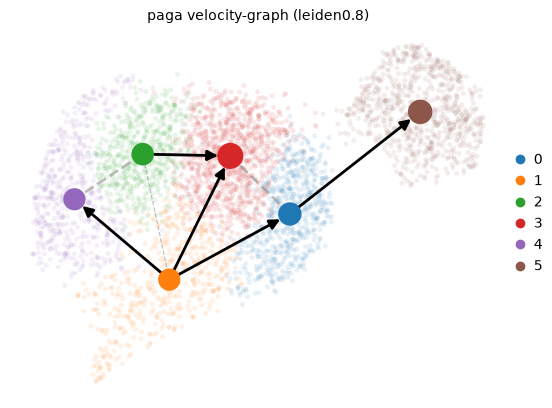

In [50]:
scv.pl.paga(adata, basis='umap', size=50, alpha=.1,
            min_edge_width=2, node_size_scale=1.5)

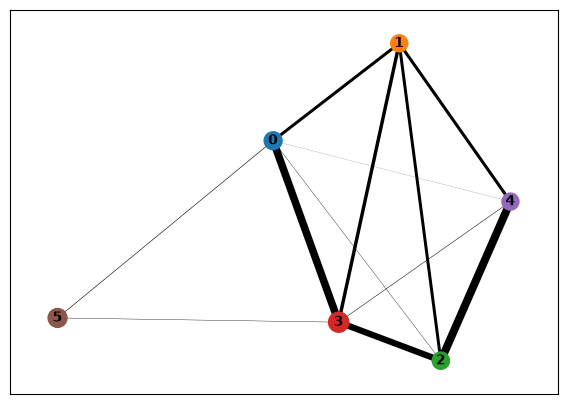

In [15]:
sc.pl.paga(adata)

## Scanpy stuff
- visualizing expression of genes of interest
- finding marker genes per cluster

### Marker genes

In [ ]:
sc.tl.rank_genes_groups(adata, 'leiden0.8', key_added="rank_genes_groups", method='wilcoxon', corr_method="bonferroni")

In [ ]:
adata

In [ ]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5, standard_scale='var')

In [ ]:
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=4,
    values_to_plot="logfoldchanges",
    min_logfoldchange=1.5,
    vmax=2,
    vmin=-2,
    cmap="bwr",
)

In [ ]:
sc.pl.rank_genes_groups_heatmap(
    adata,
    n_genes=5,
    use_raw=False,
    swap_axes=True,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    #layer="scaled",
    figsize=(10, 7),
    show=False,
)

In [ ]:
sc.pl.rank_genes_groups_stacked_violin(adata, n_genes=3, cmap="coolwarm")

In [ ]:
sc.pl.rank_genes_groups_matrixplot(adata, n_genes=5, use_raw=False, swap_axes=True,
                                   values_to_plot='logfoldchanges',
                                   vmin=-4, vmax=4, cmap="coolwarm", dendrogram=True,
                                   save='top5_lfc_heatmap.svg'
                                   )

In [ ]:
#need list of top genes so i can mess with em in inkscape 
result_df = sc.get.rank_genes_groups_df(adata, group=None)
result_df

In [ ]:
result_df.to_csv('scanpy_leiden0.8_marker_genes_df.csv', index=False)

In [ ]:
#got list with annotated names but also need gene symbols for GOAtools
adata.var["gene_id_description"] = adata.var_names
adata.var_names = adata.var["symbol"].astype(str)
adata.var

In [ ]:
# Convert the index to strings explicitly
adata.var.index = adata.var.index.astype(str)

In [ ]:
# Re-run the ranking so the internal storage uses strings
sc.tl.rank_genes_groups(adata, groupby="leiden0.8")

In [ ]:
result_df = sc.get.rank_genes_groups_df(adata, group=None)
result_df

In [ ]:
result_df.to_csv('scanpy_leiden0.8_marker_genes_unannot_df.csv', index=False)

### Genes of interest

#### expression of bulk GOIs (from ch2 adult bulk data)

In [ ]:
matched_genes.index

In [ ]:
TFs = [
  "uncharacterized_LOC145267028",#_HHEX*",
  "uncharacterized_LOC145291535",#_RUNX1*",
  "transcription_factor_GATA-3-like_LOC145296204",#_transcription_factor_GATA-3-like",
  "sushi__von_Willebrand_factor_type_A__EGF_and_pentraxin_domain-containing_protein_1-like_LOC145249753",#_sushi,_von_Willebrand_factor_type_A,_EGF_and_pentraxin_domain-containing_protein_1-like",
  "ETS-related_transcription_factor_Elf-2-like_LOC145259310",#_ETS-related_transcription_factor_Elf-2-like"
  ]
  
  #HNRNPs
HNRNPs = [
  "heterogeneous_nuclear_ribonucleoproteins_A2/B1-like_LOC145255650",#_heterogeneous_nuclear_ribonucleoproteins_A2/B1-like",
  "heterogeneous_nuclear_ribonucleoproteins_A1_homolog_LOC145255648",#_heterogeneous_nuclear_ribonucleoproteins_A1_homolog",
  "heterogeneous_nuclear_ribonucleoprotein_A1-like_3_LOC145258173",#_heterogeneous_nuclear_ribonucleoprotein_A1-like_3",
  "heterogeneous_nuclear_ribonucleoprotein_U-like_protein_1_LOC145260563",#_heterogeneous_nuclear_ribonucleoprotein_U-like_protein_1",
  "heterogeneous_nuclear_ribonucleoprotein_K-like_LOC145276714",#_heterogeneous_nuclear_ribonucleoprotein_K-like",
  ]

actin = [
  #Actin-mediated cytoplasmic bridge
  "actin__cytoplasmic_1-like_LOC145259195",#_actin,_cytoplasmic_1-like",
  "actin-related_protein_5-like_LOC145241409",#_actin-related_protein_5-like",
  "coactosin-like_protein_LOC145243680",#_coactosin-like_protein",
  "actin-related_protein_2/3_complex_subunit_5-B-like_LOC145247564",#_actin-related_protein_2/3_complex_subunit_5-B-like",
  "kinesin-like_protein_KIF11-A_LOC145245752",#_kinesin-like_protein_KIF11-A"
  ]
Ras = [
  #Ras gtpase
  "rho_GDP-dissociation_inhibitor_2-like_LOC145252733",
  "ras-like_GTP-binding_protein_RHO_LOC145260529",
  "NF-kappa-B_inhibitor-interacting_Ras-like_protein_1_LOC145270024",
  "GTPase_KRas-like_LOC145239760",
  "ras-related_protein_M-Ras-like_LOC145263723",
  ]
PRRs = [
       'peptidoglycan-recognition_protein_SC2-like_LOC145291335',
       'scavenger_receptor_cysteine-rich_domain_superfamily_protein-like_LOC145266610',
        'T-cell_immunomodulatory_protein-like_LOC145296256',
       'toll-like_receptor_4_LOC145254925',
       'galectin-3-binding_protein_A-like_LOC145279619',
  ]
Iron = [
  #Iron regulation
  "hephaestin-like_protein_LOC145283795",
  "ferritin-1_heavy_chain-like_LOC145246871",
  "soma_ferritin-like_LOC145242702",
  "iron-sulfur_cluster_transfer_protein_NUBPL-like_LOC145254756",#_iron-sulfur_cluster_transfer_protein_NUBPL-like",
  "succinate_dehydrogenase_[ubiquinone]_iron-sulfur_subunit__mitochondrial-like_LOC145241961",
]
GOIs = {"TFs":TFs,
        'HNRNPs':HNRNPs,
        "Actin Reg.":actin,
        "Ras GTPase Reg.":Ras,
        "PRRs":PRRs,
        "Iron Reg.":Iron
}

In [ ]:
import re

gene_vector = PRRs

# 1. Escape special regex characters and join them with a pipe '|' (means OR)
regex_pattern = "|".join(map(re.escape, gene_vector))

In [ ]:
matched_genes = adata.var[adata.var.index.str.contains(regex_pattern)]

ok back to plots - but need to annotate this post cellsweep/somewhat scanpy adata with the cluster label annotations from the scvelo adata

In [ ]:
adata_source = sc.read_h5ad(filename="kb_cellsweep_scvelo_sc_adata.h5ad")
adata_target = adata #this is cell sweep

In [ ]:
# 1. Ensure the cells (obs_names) match or align between both AnnData objects
# If they have the exact same cell barcodes in the same order:
adata_target.obs["leiden0.8"] = adata_source.obs["leiden0.8"].values

# 2. If indices/barcodes are out of order, map them using the index:
adata_target.obs["clusters"] = adata_source.obs.loc[
    adata_target.obs_names, "clusters"
].values
adata_target.obs["cell_type"] = adata_source.obs.loc[
    adata_target.obs_names, "cell_type"
].values

In [ ]:
adata_target
adata = adata_target

In [ ]:
%matplotlib inline


In [ ]:
#now do fiolin plots

fig, (ax) = plt.subplots(figsize=(3, 8))

sc.pl.stacked_violin(adata, GOIs,
                   ax=ax, swap_axes=True, 
                   dendrogram=True, groupby='leiden0.8', 
                   standard_scale="var",
                   show=True, #return_fig = True
                   cmap='inferno',
                   )
fig.savefig('expression_for_bulk_data.svg', format="svg")
plt.show()


In [ ]:
adata.uns['leiden0.8_colors']

In [ ]:
group_colors = {#tissue_type
    '0':'#a1c9f4',
    '1':'#ffb482',
    '2':'#8de5a1',
    '3':'#ff9f9b',
    '4':'#d0bbff',
    '5':'#debb9b',
    }
type(group_colors)

In [ ]:
#showing genes
#pull from GOIs above

fig, (ax) = plt.subplots(figsize=(5, 10))
vp = sc.pl.dotplot(adata, GOIs,
                   ax=ax, swap_axes=True, 
                   dendrogram=False, groupby='leiden0.8', 
                   standard_scale="var", group_colors=group_colors, 
                   show=False, return_fig = True)
vp.add_totals(sort = None, 
    color= adata.uns['leiden0.8_colors']).show()#.style(ylim=(0,5)).show()
#fig.savefig('.svg', format="svg")

## Saving 

In [ ]:
ad.settings.allow_write_nullable_strings = True

In [ ]:
adata.write_h5ad(filename="kb_cellsweep_scvelo_sc_adata.h5ad")

In [37]:
adata = sc.read_h5ad(filename="kb_cellsweep_scvelo_sc_adata.h5ad")

## GO Annotation inshallah
- need to reinstall GOAtools here

In [ ]:
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
import seaborn as sns
%matplotlib inline

#extracting sym clusters from adata - use kb env for this 
#import scanpy as sc, anndata as ad, 

### Reading in scanpy marker data to get top genes in LOC format


In [ ]:
#reading in scanpy marker data to get top genes in LOC format

df = pd.read_csv('scanpy_leiden0.8_marker_genes_unannot_df.csv',
                 sep=',')

In [ ]:
df

In [ ]:
zero_degs = df.loc[df['group'] == 0]
one_degs = df.loc[df['group'] == 1]
two_degs = df.loc[df['group'] == 2]
three_degs = df.loc[df['group'] == 3]
four_degs = df.loc[df['group'] == 4]
five_degs = df.loc[df['group'] == 5]

In [ ]:
zero_degs_lfc = zero_degs[zero_degs['logfoldchanges'] > 1]
zero_degs_lfc_padj = zero_degs_lfc[zero_degs_lfc['pvals_adj'] < 0.01]

one_degs_lfc = one_degs[one_degs['logfoldchanges'] > 1]
one_degs_lfc_padj = one_degs_lfc[one_degs_lfc['pvals_adj'] < 0.01]

two_degs_lfc = two_degs[two_degs['logfoldchanges'] > 1]
two_degs_lfc_padj = two_degs_lfc[two_degs_lfc['pvals_adj'] < 0.01]

three_degs_lfc = three_degs[three_degs['logfoldchanges'] > 1]
three_degs_lfc_padj = three_degs_lfc[three_degs_lfc['pvals_adj'] < 0.01]

four_degs_lfc = four_degs[four_degs['logfoldchanges'] > 1]
four_degs_lfc_padj = four_degs_lfc[four_degs_lfc['pvals_adj'] < 0.01]

five_degs_lfc = five_degs[five_degs['logfoldchanges'] > 1]
five_degs_lfc_padj = five_degs_lfc[five_degs_lfc['pvals_adj'] < 0.01]

In [ ]:
#and extracting gene names
zero_gene_names = zero_degs_lfc_padj[['names']]
one_gene_names = one_degs_lfc_padj[['names']]
two_gene_names = two_degs_lfc_padj[['names']]
three_gene_names = three_degs_lfc_padj[['names']]
four_gene_names = four_degs_lfc_padj[['names']]
five_gene_names = five_degs_lfc_padj[['names']]

In [ ]:
#and saving as txt file
zero_gene_names.to_csv('scanpy_DEG_IDs/cluster_0_geneIDs.txt', index=False, header=False,)
one_gene_names.to_csv('scanpy_DEG_IDs/cluster_1_geneIDs.txt', index=False, header=False,)
two_gene_names.to_csv('scanpy_DEG_IDs/cluster_2_geneIDs.txt', index=False, header=False,)
three_gene_names.to_csv('scanpy_DEG_IDs/cluster_3_geneIDs.txt', index=False, header=False,)
four_gene_names.to_csv('scanpy_DEG_IDs/cluster_4_geneIDs.txt', index=False, header=False,)
five_gene_names.to_csv('scanpy_DEG_IDs/cluster_5_geneIDs.txt', index=False, header=False,)

In [ ]:
gene_name = zero_gene_names
gene_name

In [ ]:
gene_names = pd.read_csv('scanpy_DEG_IDs/cluster_0_geneIDs.txt', 
                         sep=',', header=None)
gene_names

### Barplots of DEG counts per cluster
- to add still

### Setting up 

In [ ]:
#!python ~/miniconda3/envs/goatools_env/bin/ncbi_gene_results_to_python.py \
#    -o genes_ncbi_eup_scolo_proteincoding.py \
#        '/labs/Nyholm/scsnRNASeq/parse_combined_atlas_subcluster/goatools_dir/gene_result.txt'

In [ ]:
from genes_ncbi_eup_scolo_proteincoding import GENEID2NT as GeneID2nt_es

In [ ]:
from goatools.base import download_go_basic_obo
from goatools.base import download_ncbi_associations
from goatools.obo_parser import GODag
from goatools.anno.genetogo_reader import Gene2GoReader
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS
import pandas as pd
from statsmodels.stats.multitest import multipletests

In [ ]:
obo_fname = download_go_basic_obo()
fin_gene2go = download_ncbi_associations()
obodag = GODag("go-basic.obo")

In [ ]:
mapper = {}

for key in GeneID2nt_es:
    mapper[GeneID2nt_es[key].Symbol] = GeneID2nt_es[key].GeneID
    
inv_map = {v: k for k, v in mapper.items()}

In [ ]:
# Read NCBI's gene2go. Store annotations in a list of namedtuples
objanno = Gene2GoReader(fin_gene2go, taxids=[6613])
# Get namespace2association where:
#    namespace is:
#        BP: biological_process               
#        MF: molecular_function
#        CC: cellular_comptwentyonent
#    assocation is a dict:
#        key: NCBI GeneID
#        value: A set of GO IDs associated with that gene
ns2assoc = objanno.get_ns2assc()

In [ ]:
goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_es.keys(), # List of scolopes protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.05, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction method

In [ ]:
#run twentyone time to initialize
GO_items = []

temp = goeaobj.ns2objgoea['BP'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['CC'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['MF'].assoc
for item in temp:
    GO_items += temp[item]

### Running

In [ ]:
#pass list of gene symbols
def go_it(test_genes):
    print(f'input genes: {len(test_genes)}')
    
    mapped_genes = []
    for gene in test_genes:
        try:
            mapped_genes.append(mapper[gene])
        except:
            pass
    print(f'mapped genes: {len(mapped_genes)}')
    
    goea_results_all = goeaobj.run_study(mapped_genes)
    goea_results_sig = [r for r in goea_results_all if r.p_fdr_bh < 0.05]
    GO = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                   x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: inv_map[y], x.study_items)),\
                   ], goea_results_sig)), columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes',\
                                                    'n_study', 'n_go', 'study_genes'])

    GO = GO[GO.n_genes > 1]
    return GO

In [ ]:
gene_names = pd.read_csv('scanpy_DEG_IDs/cluster_0_geneIDs.txt', 
                         sep=',', header=None)
gene_names.head()

In [ ]:
gene_names

In [ ]:
df = go_it(gene_names[0].values)

In [ ]:
df

### Saving results

In [ ]:
#saving results
df.to_csv("goatools_res/cluster5_DEGs_GOAtools_df.csv", sep='\t')


#No enrichment in cluster 0
#cluster1_DEGs_GOAtools_df.csv
#No enrichment in cluster 2
#No enrichment in cluster 3
#cluster4_DEGs_GOAtools_df
#cluster5_DEGs_GOAtools_df

### Visualzing results

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import seaborn as sns
import textwrap

In [ ]:
#extract each GO term type 
df_bp = df.loc[df['class'] == 'biological_process']
df_bp = df_bp[0:10]
df_cc = df.loc[df['class'] == 'cellular_comptwentyonent']
df_cc = df_cc[0:10]
df_mf = df.loc[df['class'] == 'molecular_function']
df_mf = df_mf[0:10]

In [ ]:
#ID stats
df['per'] = df.n_genes/df.n_go
df = df[0:10]

In [ ]:
df

In [ ]:
#p.adj sig. pallette
fig, ax = plt.subplots(figsize = (0.5, 2.75))

cmap = mpl.cm.bwr_r
norm = mpl.colors.Normalize(vmin = df.p_corr.min(), vmax = df.p_corr.max())

mapper = cm.ScalarMappable(norm = norm, cmap = cm.bwr_r)

cbl = mpl.colorbar.ColorbarBase(ax, cmap = cmap, norm = norm, orientation = 'vertical')
plt.savefig('goatools_res/clst5_bar.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
plt.figure(figsize = (4,6))

ax = sns.barplot(data = df, x = 'per', y = 'term', palette = mapper.to_rgba(df.p_corr.values))

ax.set_yticklabels([textwrap.fill(e, 22) for e in df['term']])

#add axes labels
ax.set(xlabel='Genes Per GO Term', ylabel='Top 10 GO Terms')

plt.savefig('goatools_res/go_enrichment_cluster5.png', dpi=300, bbox_inches='tight')

plt.show()